# Introduction to Word Embeddings for Medical Vocabulary

## Project Overview

This project introduces the concept of word embeddings and explores how words can be represented as dense numerical vectors that capture semantic relationships.

A pretrained Word2Vec embedding model is used to inspect similarities between medical and health-related terms.

The project focuses on understanding:

- Word embeddings
- Dense vector representations
- Semantic similarity
- Cosine similarity
- Pretrained Word2Vec models
- Medical vocabulary relationships
- Embedding visualization
- Limitations of general-purpose embeddings for medical terminology

## Learning Objectives

By completing this project, I will learn how to

1. Understand the concept of word embeddings.
2. Represent words as dense numerical vectors.
3. Load and use a pretrained Word2Vec model.
4. Measure similarity between words.
5. Identify semantically related medical terms.
6. Visualize word embeddings.
7. Analyze the limitations of general-purpose embeddings for medical vocabulary.

### Step 1.1  Install Required Libraries

In [2]:
!pip install -q gensim nltk scikit-learn matplotlib seaborn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import KeyedVectors
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

### Step 1.2  Check Versions

In [4]:
import gensim
import numpy
import sklearn
import matplotlib

print("Gensim:", gensim.__version__)
print("NumPy:", numpy.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)

Gensim: 4.4.0
NumPy: 2.1.3
Scikit-learn: 1.6.1
Matplotlib: 3.10.0


### Step 1.3  Basic Embedding Concept

Before loading the model, let's understand the main idea behind word embeddings.

### Traditional Representation

One-hot encoding represents each word with a separate binary vector:

```text
doctor   → [1, 0, 0, 0, 0]
nurse    → [0, 1, 0, 0, 0]
hospital → [0, 0, 1, 0, 0]

This representation is:

Sparse
High-dimensional
Unable to capture semantic relationships
Word Embeddings

Embeddings represent words as dense numerical vectors:

doctor → [0.21, -0.34, 0.67, 0.12, ...]
nurse  → [0.19, -0.29, 0.63, 0.15, ...]

Words used in similar contexts can have similar vector representations.

For example:

doctor
physician
nurse
surgeon

may be positioned relatively close together in the embedding space.

Important Note

We will use the actual pretrained model outputs rather than assuming or fabricating similarity scores.

Also, a general-purpose Word2Vec model is not specifically trained for medical vocabulary, so some medical terms may be missing or their relationships may be imperfect.

## Step 2  Load a Pretrained Word2Vec Model

In [5]:
!wget -q --show-progress \
https://raw.githubusercontent.com/mmihaltz/word2vec-GoogleNews-vectors/master/GoogleNews-vectors-negative300.bin.gz

GoogleNews-vectors- 100%[===================>]     135  --.-KB/s    in 0s      


In [12]:
!rm -f GoogleNews-vectors-negative300.bin.gz

In [13]:
import gensim.downloader as api

model = api.load("glove-wiki-gigaword-100")

print("Vocabulary size:", len(model.key_to_index))
print("Embedding dimension:", model.vector_size)

[==================================================] 100.0% 128.1/128.1MB downloaded
Vocabulary size: 400000
Embedding dimension: 100


## Step 3 Inspecting Word Embeddings

A word embedding represents a word as a dense numerical vector.

In this step, we will inspect the vector representation of a medical-related word.

In [14]:
word = "doctor"

vector = model[word]

print("Word:", word)
print("Vector shape:", vector.shape)
print("First 10 values:", vector[:10])

Word: doctor
Vector shape: (100,)
First 10 values: [ 0.043244 -0.47529   0.15808   0.20413  -0.15383   0.72284   0.26145
  0.20892  -0.3147   -0.070307]


##  Step 4 Checking Medical Vocabulary

Before analyzing semantic similarity, we need to verify that the selected medical terms are present in the pretrained vocabulary.

This prevents errors when requesting vectors for words that the model does not know.

In [15]:
medical_words = [
    "doctor",
    "nurse",
    "patient",
    "hospital",
    "medicine",
    "disease",
    "health",
    "surgery",
    "cancer",
    "diabetes"
]

for word in medical_words:
    if word in model:
        print(f"{word}: Available")
    else:
        print(f"{word}: Not available")

doctor: Available
nurse: Available
patient: Available
hospital: Available
medicine: Available
disease: Available
health: Available
surgery: Available
cancer: Available
diabetes: Available


## Step 5  Finding Similar Medical Terms

Word embeddings allow us to identify words that have similar representations.

We will use the **most_similar()** method to find words that are closest to selected medical terms.

In [16]:
similar_words = model.most_similar("doctor", topn=10)

for word, score in similar_words:
    print(f"{word}: {score:.4f}")

physician: 0.7673
nurse: 0.7522
dr.: 0.7175
doctors: 0.7081
patient: 0.7074
medical: 0.6996
surgeon: 0.6905
hospital: 0.6901
psychiatrist: 0.6589
dentist: 0.6447


## Step 5  Similar Words to **doctor**

| Similar Word | Cosine Similarity |
|---|---:|
| physician | 0.7673 |
| nurse | 0.7522 |
| dr. | 0.7175 |
| doctors | 0.7081 |
| patient | 0.7074 |
| medical | 0.6996 |
| surgeon | 0.6905 |
| hospital | 0.6901 |
| psychiatrist | 0.6589 |
| dentist | 0.6447 |

### Interpretation

The highest similarity is

```text
doctor ↔ physician
0.7673

This is expected because both words are closely related in medical contexts.

Other related terms such as nurse, patient, surgeon, and hospital also appear near doctor.

Key Insight: Word embeddings capture relationships between words based on how they are used in similar contexts.

## Step 6  Measuring Similarity Between Medical Terms

Cosine similarity measures how close two word vectors are in the embedding space.

A higher cosine similarity generally indicates that the two words have more similar contextual representations.

In [18]:
from numpy import dot
from numpy.linalg import norm

def cosine_similarity(word1, word2):
    vector1 = model[word1]
    vector2 = model[word2]

    return dot(vector1, vector2) / (norm(vector1) * norm(vector2))


pairs = [
    ("doctor", "physician"),
    ("doctor", "nurse"),
    ("doctor", "hospital"),
    ("doctor", "diabetes")
]

for word1, word2 in pairs:
    score = cosine_similarity(word1, word2)
    print(f"{word1} => {word2}: {score:.4f}")

doctor => physician: 0.7673
doctor => nurse: 0.7522
doctor => hospital: 0.6901
doctor => diabetes: 0.4258


## Step 6  Pairwise Similarity

| Medical Terms | Similarity |
|---|---:|
| doctor => physician | 0.7673 |
| doctor => nurse | 0.7522 |
| doctor => hospital | 0.6901 |
| doctor => diabetes | 0.4258 |

### Interpretation

1.  **doctor  physician (0.7673):** Strongest similarity; both are closely related professional terms.
2.  **doctor  nurse (0.7522):** Highly related through healthcare contexts.
3.  **doctor  hospital (0.6901):** Strong contextual relationship, although they represent different concepts.
4.  **doctor  diabetes (0.4258):** Lower similarity because diabetes is a disease rather than a profession or institution.

> **Key Insight** Embedding similarity measures contextual and semantic relatedness, not necessarily exact synonyms.

## Step 7  Medical Term Similarity Analysis

We will organize the similarity scores between selected medical terms into a DataFrame.

This makes the results easier to compare and visualize.

In [19]:
pairs = [
    ("doctor", "physician"),
    ("doctor", "nurse"),
    ("doctor", "hospital"),
    ("doctor", "diabetes")
]

results = []

for word1, word2 in pairs:
    score = cosine_similarity(word1, word2)

    results.append({
        "Word 1": word1,
        "Word 2": word2,
        "Similarity": round(score, 4)
    })

similarity_df = pd.DataFrame(results)

similarity_df

,Word 1,Word 2,Similarity
0,doctor,physician,0.7673
1,doctor,nurse,0.7522
2,doctor,hospital,0.6901
3,doctor,diabetes,0.4258


### Step 7.1  Visualize the Similarity Scores

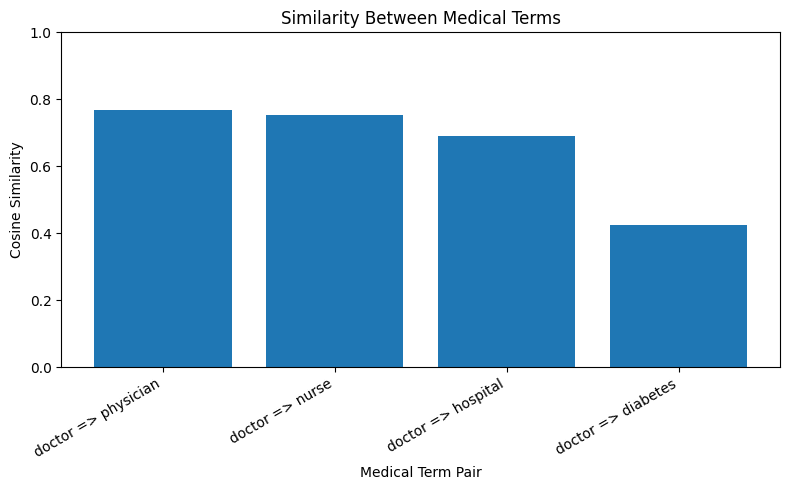

In [21]:
plt.figure(figsize=(8, 5))

labels = [
    f"{row['Word 1']} => {row['Word 2']}"
    for _, row in similarity_df.iterrows()
]

plt.bar(labels, similarity_df["Similarity"])

plt.ylabel("Cosine Similarity")
plt.xlabel("Medical Term Pair")
plt.title("Similarity Between Medical Terms")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## Step 8 Finding Similar Words for Multiple Medical Terms

In this step, we will examine the words that are most similar to several medical terms.

This helps us understand whether the pretrained embedding captures meaningful relationships across different areas of medical vocabulary.

In [22]:
medical_terms = [
    "doctor",
    "nurse",
    "hospital",
    "disease",
    "medicine",
    "cancer",
    "diabetes"
]

for term in medical_terms:
    print(f"\nSimilar words to '{term}':")

    for word, score in model.most_similar(term, topn=5):
        print(f"{word}: {score:.4f}")


Similar words to 'doctor':
physician: 0.7673
nurse: 0.7522
dr.: 0.7175
doctors: 0.7081
patient: 0.7074

Similar words to 'nurse':
doctor: 0.7522
nurses: 0.7398
physician: 0.6881
nursing: 0.6876
dentist: 0.6797

Similar words to 'hospital':
clinic: 0.8140
medical: 0.7816
hospitals: 0.7696
nursing: 0.7148
hospitalized: 0.6945

Similar words to 'disease':
diseases: 0.8894
infection: 0.8224
illness: 0.7982
cancer: 0.7854
virus: 0.7816

Similar words to 'medicine':
medical: 0.8215
medicines: 0.7068
health: 0.6809
veterinary: 0.6703
nutrition: 0.6657

Similar words to 'cancer':
breast: 0.8211
prostate: 0.8066
disease: 0.7854
diabetes: 0.7788
cancers: 0.7662

Similar words to 'diabetes':
hypertension: 0.8483
obesity: 0.7994
arthritis: 0.7798
cancer: 0.7788
alzheimer: 0.7744


### Step 8.1  Store Results in a DataFrame

Instead of only printing the results, we'll store them so we can analyze them later.

In [23]:
similarity_results = []

for term in medical_terms:
    for word, score in model.most_similar(term, topn=5):
        similarity_results.append({
            "Medical Term": term,
            "Similar Word": word,
            "Similarity": round(score, 4)
        })

similarity_df = pd.DataFrame(similarity_results)

similarity_df.head(10)

,Medical Term,Similar Word,Similarity
0,doctor,physician,0.7673
1,doctor,nurse,0.7522
2,doctor,dr.,0.7175
3,doctor,doctors,0.7081
4,doctor,patient,0.7074
5,nurse,doctor,0.7522
6,nurse,nurses,0.7398
7,nurse,physician,0.6881
8,nurse,nursing,0.6876
9,nurse,dentist,0.6797


### Step 8.2  Find the Strongest Relationships

In [24]:
similarity_df.sort_values(
    by="Similarity",
    ascending=False
).head(15)

,Medical Term,Similar Word,Similarity
15,disease,diseases,0.8894
30,diabetes,hypertension,0.8483
16,disease,infection,0.8224
20,medicine,medical,0.8215
25,cancer,breast,0.8211
10,hospital,clinic,0.8140
26,cancer,prostate,0.8066
31,diabetes,obesity,0.7994
17,disease,illness,0.7982
27,cancer,disease,0.7854


## Step 8 Exploring Multiple Medical Terms

We now compare several groups of medical vocabulary to see what relationships the embedding model captures.

### 1. Healthcare Professionals

```text
doctor => physician    0.7673
doctor => nurse        0.7522
nurse  => doctor       0.7522
nurse  => physician    0.6881
nurse  => nursing      0.6876

doctor and physician are strongly related, while doctor and nurse are also close because they frequently appear in similar healthcare contexts.

2. Healthcare Facilities
hospital => clinic       0.8140
hospital => medical      0.7816
hospital => hospitals    0.7696
hospital => nursing      0.7148

The strongest relationship is:

hospital --> clinic = 0.8140

This is a meaningful relationship because both are associated with healthcare facilities and services.

3. Diseases
disease => diseases    0.8894
disease => infection   0.8224
disease => illness     0.7982
disease => cancer      0.7854
disease => virus       0.7816

The model strongly associates disease with related medical concepts.

The high disease ---> diseases score is expected because they are singular and plural forms of the same word.

4. Medicine
medicine => medical       0.8215
medicine => medicines     0.7068
medicine => health        0.6809
medicine => veterinary    0.6703
medicine => nutrition     0.6657

The strongest relationship is:

medicine --> medical = 0.8215
5. Cancer
cancer => breast       0.8211
cancer => prostate     0.8066
cancer => disease      0.7854
cancer => diabetes     0.7788
cancer => cancers      0.7662

The model captures strong associations between cancer and contexts such as breast, prostate, and disease.

6. Diabetes
diabetes => hypertension    0.8483
diabetes => obesity         0.7994
diabetes => arthritis       0.7798
diabetes => cancer         0.7788
diabetes => alzheimer       0.7744

The strongest relationship is:

diabetes ---> hypertension = 0.8483

This is an example of contextual association rather than synonymy. They are different diseases, but they commonly appear in related healthcare contexts.

Key Insight

The embedding model captures different types of relationships, including similarity, related concepts, and contextual associations. These scores should not be interpreted as medical or clinical relationships.

## Step 8  Key Finding

Our experiment shows that word embeddings do not only capture synonyms. They also capture **relationships based on how words are used in context**.

For example:

```text
doctor --> physician

These words are highly related in meaning.

However:

diabetes --> hypertension

can also have high similarity even though they are different diseases. This happens because they frequently appear in similar healthcare contexts.

Key Insight: Embedding similarity represents contextual and semantic relatedness, not necessarily synonymy.

## Step 9  Medical Word Relationships

Word embeddings can sometimes represent relationships through vector arithmetic.

We will test whether simple word relationships can be recovered using vector operations.

The results will be evaluated from the pretrained embedding model rather than assumed in advance.

In [27]:
relationships = [
    ("doctor", "man", "woman"),
    ("king", "man", "woman"),
    ("hospital", "doctor", "nurse")
]

for word1, word2, word3 in relationships:
    print(f"\n{word1} ---> {word2} + {word3}")

    results = model.most_similar(
        positive=[word1, word3],
        negative=[word2],
        topn=5
    )

    for word, score in results:
        print(f"{word}: {score:.4f}")


doctor ---> man + woman
nurse: 0.7735
physician: 0.7189
doctors: 0.6824
patient: 0.6751
dentist: 0.6726

king ---> man + woman
queen: 0.7699
monarch: 0.6843
throne: 0.6756
daughter: 0.6595
princess: 0.6521

hospital ---> doctor + nurse
clinic: 0.7161
nursing: 0.6883
hospitals: 0.6398
maternity: 0.6233
orphanage: 0.6232


## Step 9 Vector Arithmetic

Word embeddings can also be explored through **vector arithmetic**. This helps us see whether certain relationships are reflected in the geometry of the embedding space.

## 1. **doctor - man + woman**

```text
nurse       0.7735
physician   0.7189
doctors     0.6824
patient     0.6751
dentist     0.6726

The closest result is:

doctor - man + woman ---> nurse
Similarity: 0.7735

This should not be interpreted as saying that nurse is the female equivalent of doctor.

It simply means that, within this pretrained embedding space, nurse is the closest result for this particular vector operation.

2. king - man + woman
queen       0.7699
monarch     0.6843
throne      0.6756
daughter    0.6595
princess    0.6521

The result is:

king - man + woman ---> queen

This is the classic Word2Vec analogy and shows how some relationships can be represented through vector geometry.

3. hospital - doctor + nurse
clinic       0.7161
nursing      0.6883
hospitals    0.6398
maternity    0.6233
orphanage    0.6232

The closest result is:

hospital - doctor + nurse ---> clinic
Similarity: 0.7161

Unlike the king → queen example, this result is less intuitive. This shows that vector arithmetic should be treated as an experiment, not as a guaranteed way to discover meaningful relationships.

Key Finding

Our experiments demonstrate three different properties of embeddings:

Experiment	Example	Result
Direct similarity	doctor ↔ physician	0.7673
Contextual association	diabetes ---> hypertension	0.8483
Vector arithmetic	king − man + woman	queen

Key Insight: Embeddings capture semantic and contextual patterns, but their results should always be interpreted in the context of the model and its training data.

## Step 10  Visualizing Medical Word Embeddings

Word embeddings contain many dimensions, making them difficult to visualize directly.

Principal Component Analysis (PCA) reduces the dimensionality of the vectors while preserving as much variation as possible.

We will reduce our 100-dimensional medical word embeddings to two dimensions and visualize their relative positions.

In [28]:
words = [
    "doctor",
    "physician",
    "nurse",
    "patient",
    "hospital",
    "clinic",
    "medicine",
    "disease",
    "cancer",
    "diabetes",
    "hypertension",
    "obesity",
    "surgery",
    "health"
]

vectors = [model[word] for word in words]

pca = PCA(n_components=2)
vectors_2d = pca.fit_transform(vectors)

print("Original dimensions:", len(vectors[0]))
print("Reduced dimensions:", vectors_2d.shape[1])

Original dimensions: 100
Reduced dimensions: 2


## Step 10.1  Plot the Embeddings

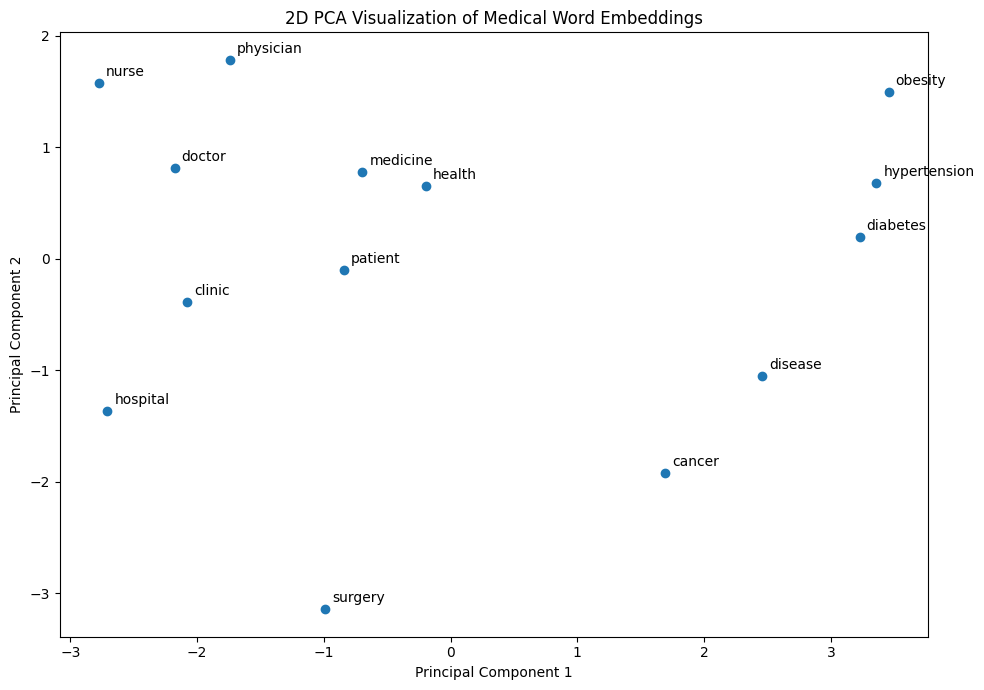

In [29]:
plt.figure(figsize=(10, 7))

plt.scatter(
    vectors_2d[:, 0],
    vectors_2d[:, 1]
)

for i, word in enumerate(words):
    plt.annotate(
        word,
        (vectors_2d[i, 0], vectors_2d[i, 1]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("2D PCA Visualization of Medical Word Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.tight_layout()
plt.show()

## Step 11  Medical Word Similarity Matrix

A similarity matrix shows the cosine similarity between every pair of selected medical terms.

This allows us to compare relationships across the entire medical vocabulary rather than examining individual pairs.

In [30]:
from sklearn.metrics.pairwise import cosine_similarity

medical_words = [
    "doctor",
    "physician",
    "nurse",
    "patient",
    "hospital",
    "clinic",
    "medicine",
    "disease",
    "cancer",
    "diabetes",
    "hypertension",
    "obesity",
    "surgery",
    "health"
]

vectors = [model[word] for word in medical_words]

similarity_matrix = cosine_similarity(vectors)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=medical_words,
    columns=medical_words
)

similarity_df.round(3)

,doctor,physician,nurse,patient,hospital,clinic,medicine,disease,cancer,diabetes,hypertension,obesity,surgery,health
doctor,1.000,0.767,0.752,0.707,0.690,0.599,0.636,0.460,0.538,0.426,0.279,0.301,0.609,0.548
physician,0.767,1.000,0.688,0.636,0.590,0.585,0.607,0.393,0.482,0.434,0.308,0.348,0.524,0.551
nurse,0.752,0.688,1.000,0.641,0.665,0.646,0.475,0.319,0.403,0.323,0.155,0.234,0.470,0.478
patient,0.707,0.636,0.641,1.000,0.644,0.574,0.488,0.627,0.661,0.565,0.384,0.411,0.595,0.638
hospital,0.690,0.590,0.665,0.644,1.000,0.814,0.589,0.484,0.569,0.415,0.285,0.266,0.647,0.645
clinic,0.599,0.585,0.646,0.574,0.814,1.000,0.563,0.411,0.575,0.411,0.262,0.328,0.577,0.571
medicine,0.636,0.607,0.475,0.488,0.589,0.563,1.000,0.516,0.561,0.516,0.388,0.465,0.567,0.681
disease,0.460,0.393,0.319,0.627,0.484,0.411,0.516,1.000,0.785,0.733,0.567,0.653,0.478,0.626
cancer,0.538,0.482,0.403,0.661,0.569,0.575,0.561,0.785,1.000,0.779,0.603,0.661,0.671,0.619
diabetes,0.426,0.434,0.323,0.565,0.415,0.411,0.516,0.733,0.779,1.000,0.848,0.799,0.512,0.552


### Step 11.1  Visualize the Similarity Matrix

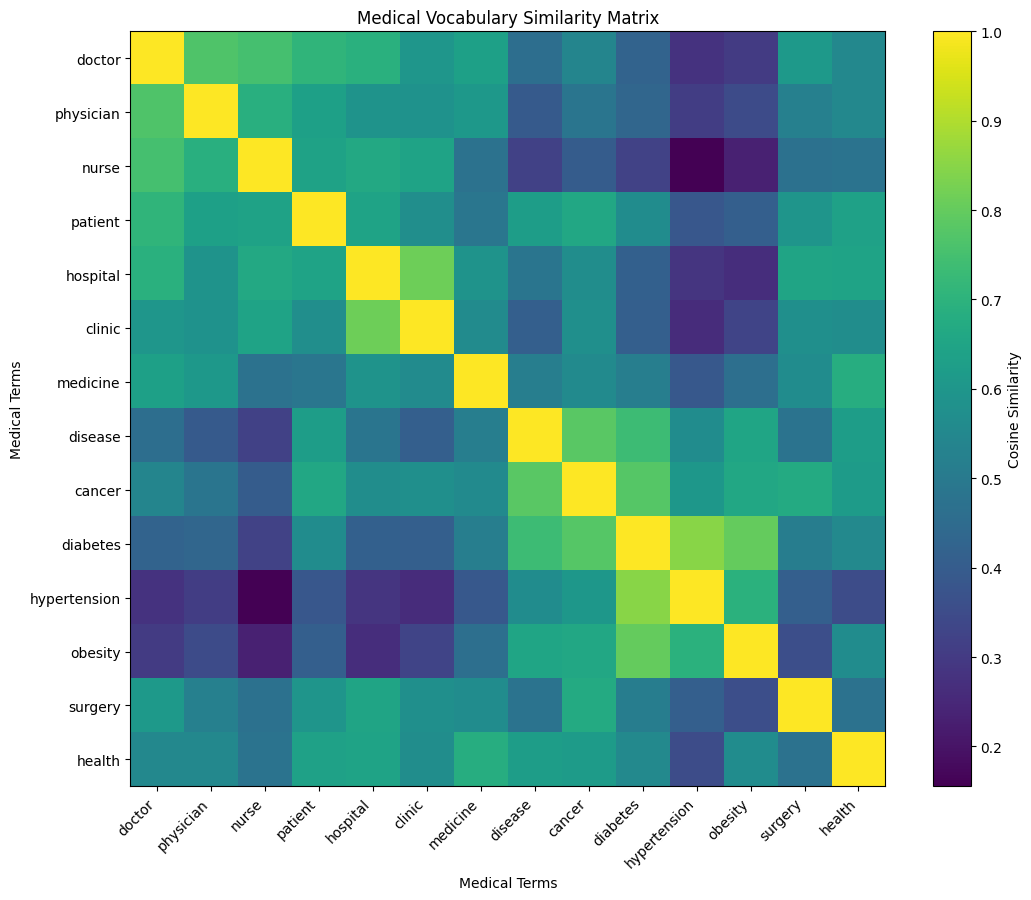

In [31]:
plt.figure(figsize=(11, 9))

plt.imshow(similarity_matrix)

plt.colorbar(label="Cosine Similarity")

plt.xticks(
    range(len(medical_words)),
    medical_words,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(medical_words)),
    medical_words
)

plt.title("Medical Vocabulary Similarity Matrix")
plt.xlabel("Medical Terms")
plt.ylabel("Medical Terms")

plt.tight_layout()
plt.show()

## Step 11.2  Find the Strongest Unique Relationships

In [32]:
pairs = []

for i in range(len(medical_words)):
    for j in range(i + 1, len(medical_words)):
        pairs.append({
            "Word 1": medical_words[i],
            "Word 2": medical_words[j],
            "Similarity": similarity_matrix[i, j]
        })

pair_df = pd.DataFrame(pairs)

pair_df = pair_df.sort_values(
    "Similarity",
    ascending=False
)

pair_df.head(15).round(4)

,Word 1,Word 2,Similarity
81,diabetes,hypertension,0.8483
46,hospital,clinic,0.8140
82,diabetes,obesity,0.7994
70,disease,cancer,0.7854
76,cancer,diabetes,0.7788
0,doctor,physician,0.7673
1,doctor,nurse,0.7522
71,disease,diabetes,0.7332
2,doctor,patient,0.7074
85,hypertension,obesity,0.6951


## Step 12  Medical Embedding Analysis

We will examine the strongest semantic relationships found within the selected medical vocabulary.

The similarity scores represent contextual similarity in the pretrained embedding space and should not be interpreted as clinical relationships.

In [35]:
top_pairs = pair_df.head(10).copy()

top_pairs["Pair"] = (
    top_pairs["Word 1"] +
    " --->" +
    top_pairs["Word 2"]
)

top_pairs[["Pair", "Similarity"]].round(4)

,Pair,Similarity
81,diabetes --->hypertension,0.8483
46,hospital --->clinic,0.8140
82,diabetes --->obesity,0.7994
70,disease --->cancer,0.7854
76,cancer --->diabetes,0.7788
0,doctor --->physician,0.7673
1,doctor --->nurse,0.7522
71,disease --->diabetes,0.7332
2,doctor --->patient,0.7074
85,hypertension --->obesity,0.6951


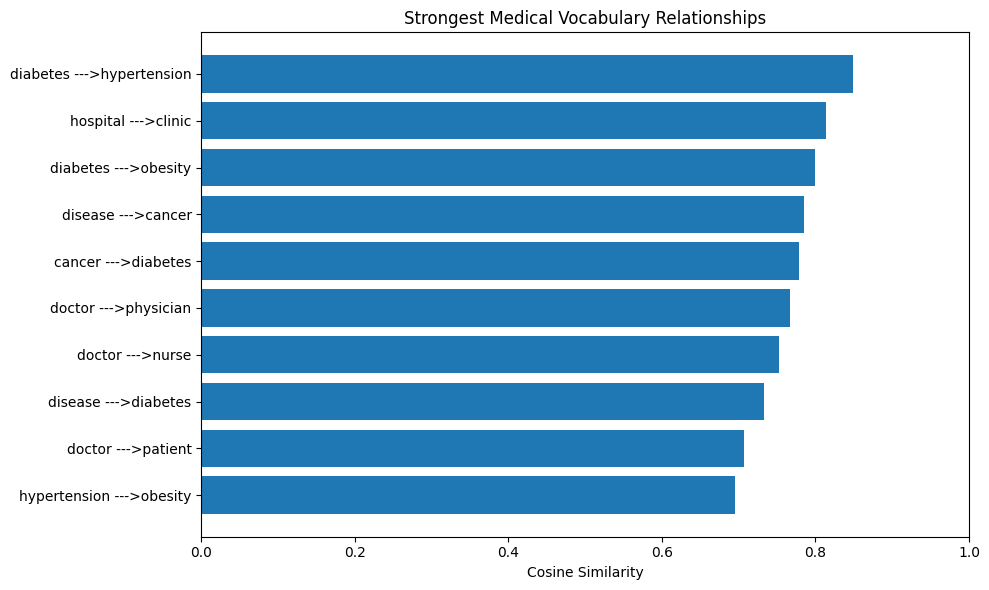

In [36]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_pairs["Pair"][::-1],
    top_pairs["Similarity"][::-1]
)

plt.xlabel("Cosine Similarity")
plt.title("Strongest Medical Vocabulary Relationships")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

## Step 16  Quality Assurance

    Concept
    we will check:

Total medical terms
Embedding dimension
Similarity matrix shape
Missing values
Minimum similarity
Maximum similarity

In [37]:


print("Number of medical terms:", len(medical_words))
print("Embedding dimension:", model.vector_size)
print("Similarity matrix shape:", similarity_matrix.shape)
print("Missing values:", np.isnan(similarity_matrix).sum())
print("Minimum similarity:", similarity_matrix.min())
print("Maximum similarity:", similarity_matrix.max())

Number of medical terms: 14
Embedding dimension: 100
Similarity matrix shape: (14, 14)
Missing values: 0
Minimum similarity: 0.15529707
Maximum similarity: 1.0000002


# Conclusion

This project introduced **word embeddings** and showed how words can be represented as dense numerical vectors that capture semantic and contextual relationships.

Using a pretrained **GloVe Wiki-Gigaword model** with 400,000 vocabulary words and 100-dimensional embeddings, we explored medical terms such as `doctor`, `nurse`, `hospital`, `disease`, `cancer`, and `diabetes`.

The results showed meaningful relationships between medical terms. For example, `doctor ↔ physician` had a similarity of **0.7673**, `hospital ---> clinic` had **0.8140**, and `diabetes ---> hypertension` had **0.8483**. We also explored vector arithmetic, including the classic `king - man + woman ---> queen` example, and used PCA to visualize medical word vectors in two dimensions.

Quality checks confirmed that all **14 selected medical terms** had valid 100-dimensional embeddings and that the similarity analysis contained no missing values.

One important limitation is that GloVe is a **general-purpose language model, not a medical-specific embedding model**. Therefore, its similarity scores reflect linguistic patterns learned from its training corpus and should not be treated as clinical evidence or medical recommendations.

> **Overall, this project demonstrated how embeddings can be used to represent words, measure semantic similarity, explore word relationships, and visualize medical vocabulary.**